<a href="https://colab.research.google.com/github/o-vvy/arbitrium.github.io/blob/master/mae146_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'cybersecurity-threat-detection-dataset' dataset.
timestamp              object
src_ip                 object
dst_ip                 object
src_port                int64
dst_port                int64
protocol               object
bytes_sent              int64
bytes_received          int64
user_agent             object
url                    object
is_internal_traffic      bool
label                   int64
attack_type            object
dtype: object

First 3 rows:
Classes: [0 1]
Training samples: 8000,  Test samples: 2000
Number of features: 25
Testing 9 architectures with 5-fold CV...

Architecture (4,)                  Mean acc: 96.09%  ±0.41%
Architecture (16,)                 Mean acc: 96.10%  ±0.42%
Architecture (32,)                 Mean acc: 96.06%  ±0.42%
Architecture (4, 4, 4, 4)          Mean acc: 96.01%  ±0.40%
Architecture (16, 16, 16, 16)      Mean acc: 95.99%  ±0.40%
Architecture (32, 32, 32, 32)      Mean acc: 95.86%  ±0.34%
Arc

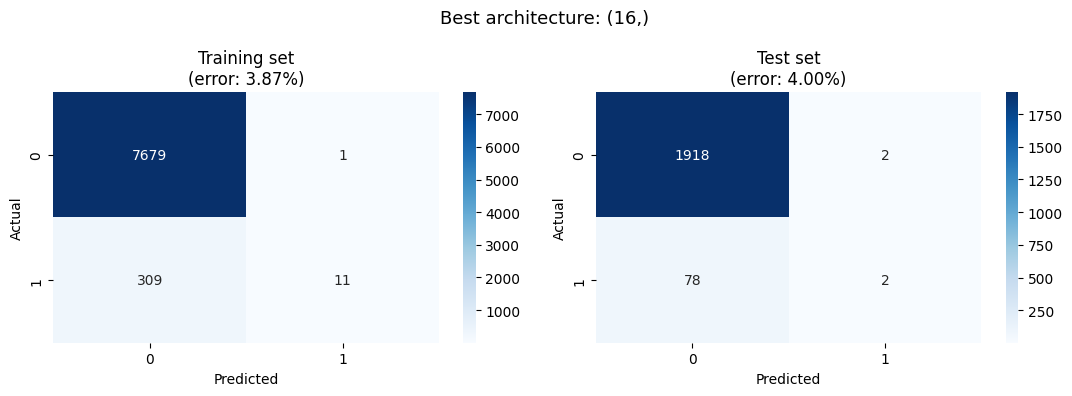

  Logistic Regression
  Training accuracy : 96.14%
  Test accuracy     : 96.05%
  Training error    : 3.86%
  Test error        : 3.95%
  Generalisation gap: 0.09%

Classification Report (Test set):
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1920
           1       1.00      0.01      0.02        80

    accuracy                           0.96      2000
   macro avg       0.98      0.51      0.50      2000
weighted avg       0.96      0.96      0.94      2000



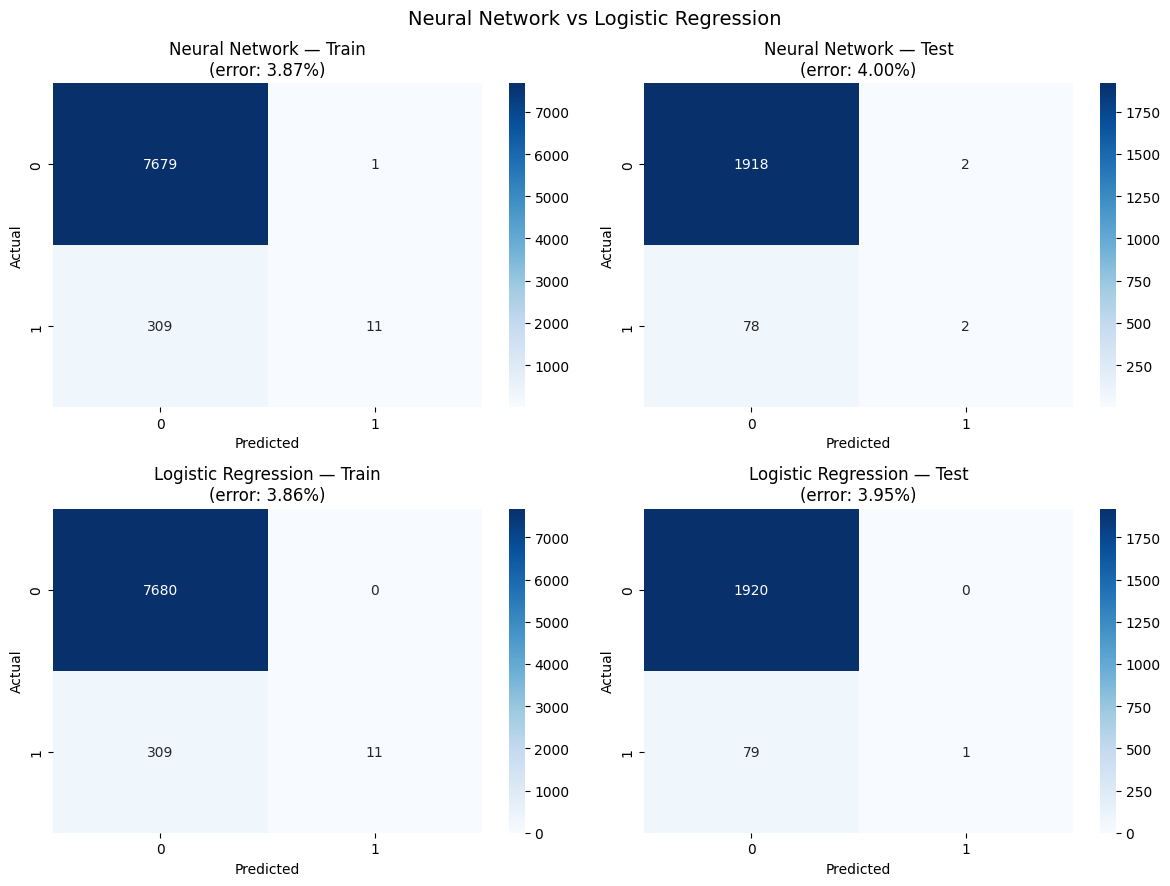


Metric                     Neural Network  Logistic Reg
Training accuracy                  96.12%        96.14%
Test accuracy                      96.00%        96.05%
Training error                      3.87%         3.86%
Test error                          4.00%         3.95%
Generalisation gap                  0.13%         0.09%

Better test accuracy: Logistic Regression
Feature importances (by LR coefficient magnitude):
bytes_sent        0.832119
user_agent_3      0.405236
user_agent_1      0.393539
dst_port          0.334469
user_agent_4      0.302712
user_agent_0      0.269631
ts_is_workhour    0.138875
user_agent_2      0.137999
dst_ip_o3         0.123213
dst_ip_o4         0.114390
protocol_enc      0.106064
ts_dayofweek      0.103685
dst_ip_o1         0.097452
ts_is_weekend     0.094048
dst_ip_o2         0.073863
src_ip_o2         0.055790
ts_hour           0.054491
src_ip_o1         0.035645
src_ip_o3         0.021434
url_0             0.010431
url_1             0.009556
ur

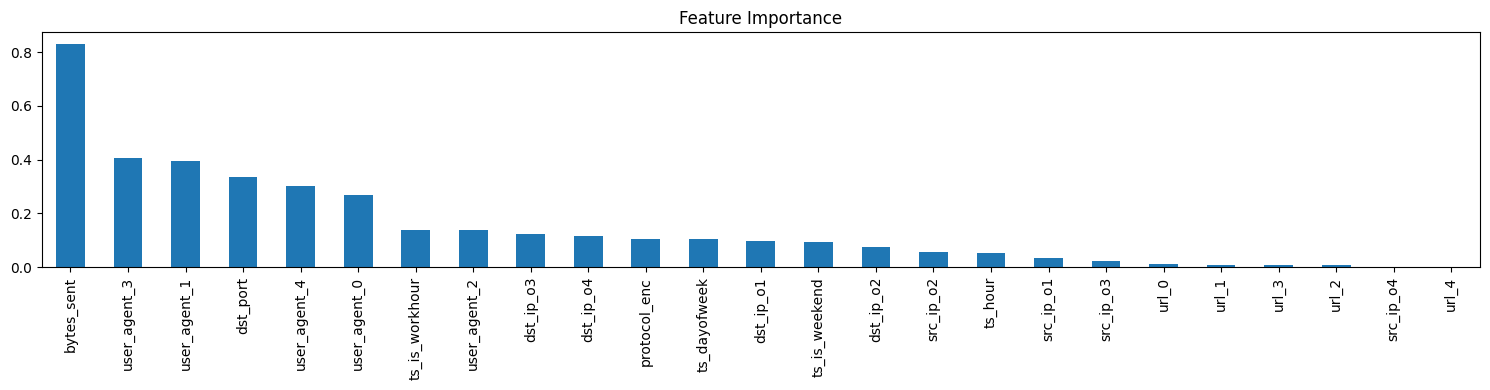

In [26]:
import pandas as pd
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import kagglehub

# SECTION A - import data, creature feature vectors

# load data
path = kagglehub.dataset_download("dhrubangtalukdar/cybersecurity-threat-detection-dataset")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

# see all column names and types
print(df.dtypes)
print("\nFirst 3 rows:")
df.head(3)

# map protocol to integers
from sklearn.preprocessing import LabelEncoder

le_protocol = LabelEncoder()
df['protocol_enc'] = le_protocol.fit_transform(df['protocol'].astype(str))

# hash strings to buckets (url and user_agent)
from sklearn.feature_extraction import FeatureHasher

def hash_column(series, n_features=5):
    """Hash a string column into n_features numeric columns."""
    hasher = FeatureHasher(n_features=n_features, input_type='string')
    hashed = hasher.transform(series.astype(str).apply(lambda x: [x]))
    return pd.DataFrame(hashed.toarray(),
                        columns=[f'{series.name}_{i}' for i in range(n_features)],
                        index=series.index)

df = pd.concat([df, hash_column(df['user_agent'], n_features=5)], axis=1)
df = pd.concat([df, hash_column(df['url'],        n_features=5)], axis=1)

# extract time stamp components
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['ts_hour']       = df['timestamp'].dt.hour          # 0-23
df['ts_dayofweek']  = df['timestamp'].dt.dayofweek     # 0=Mon, 6=Sun
df['ts_is_weekend'] = df['timestamp'].dt.dayofweek.isin([5, 6]).astype(int)
df['ts_is_workhour']= df['timestamp'].dt.hour.between(9, 17).astype(int)


FEATURE_COLS_BASE = ['src_port', 'dst_port', 'bytes_received', 'bytes_sent'] # original input feature
# FEATURE_COLS_BASE = ['dst_port', 'bytes_sent'] # alternative input feature w/out dominant features
LABEL_COL    = 'label'                     # the column with benign/attack labels

# add in non integer features
timestamp_features = ['ts_hour', 'ts_dayofweek', 'ts_is_weekend', 'ts_is_workhour']
protocol_features  = ['protocol_enc']
url_features       = [f'url_{i}'        for i in range(5)]
agent_features     = [f'user_agent_{i}' for i in range(5)]

FEATURE_COLS_NEW = FEATURE_COLS_BASE + timestamp_features + protocol_features \
             + url_features + agent_features

#extract ip octets
def ip_to_octets(df, col):
    octets = df[col].str.strip().str.split('.', expand=True).astype(float)
    octets.columns = [f'{col}_o1', f'{col}_o2', f'{col}_o3', f'{col}_o4']
    return octets

df = pd.concat([df, ip_to_octets(df, 'src_ip'), ip_to_octets(df, 'dst_ip')], axis=1)
df = df.drop(columns=['src_ip', 'dst_ip'])

# dynamically add the new IP octet columns to FEATURE_COLS
FEATURE_COLS = list(FEATURE_COLS_NEW)
for ip_col_prefix in ['src_ip', 'dst_ip']:
    for i in range(1, 5):
        FEATURE_COLS.append(f'{ip_col_prefix}_o{i}')


# Drop rows with missing values
df = df.dropna(subset=FEATURE_COLS + [LABEL_COL])

# Separate features (X) and labels (y)
X = df[FEATURE_COLS].values   # shape: (num_samples, num_features)
y = df[LABEL_COL].values

# Convert text labels like "benign"/"attack" to 0/1
le = LabelEncoder()
y = le.fit_transform(y)
print("Classes:", le.classes_)   # tells you which class is 0 and which is 1

# Split into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=53, stratify=y
)

# Standardise features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # learn scale from training data only
X_test  = scaler.transform(X_test)        # apply same scale to test data

print(f"Training samples: {len(X_train)},  Test samples: {len(X_test)}")
print(f"Number of features: {X_train.shape[1]}")

# SECTION B - set up architectures to be compared

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold
import itertools


# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

# define architecture to search over
ARCHITECTURES = list(itertools.product(
    [1, 4, 16],           # number of hidden layers
    [4, 16, 32]        # neurons per hidden layer (same size for all layers)
))
# Converts to list of tuples
ARCHITECTURES = [tuple([size] * n_layers) for n_layers, size in ARCHITECTURES]

EPOCHS   = 20
K_FOLDS  = 5     # number of cross-validation folds
n_features = X_train.shape[1]

# SECTION C - training and evalution functions

def build_model(layer_sizes, n_features):
    """Dynamically build a model given a tuple of hidden layer sizes."""
    layers = []
    in_size = n_features
    for out_size in layer_sizes:
        layers.append(nn.Linear(in_size, out_size))
        layers.append(nn.ReLU())
        in_size = out_size
    layers.append(nn.Linear(in_size, 1))
    layers.append(nn.Sigmoid())
    return nn.Sequential(*layers)

def train_one_fold(model, X_tr, y_tr, epochs=EPOCHS):
    """Train a model on one fold, return trained model."""
    dataset = TensorDataset(X_tr, y_tr)
    loader  = DataLoader(dataset, batch_size=64, shuffle=True)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    model.train()
    for _ in range(epochs):
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch).squeeze(), y_batch)
            loss.backward()
            optimizer.step()
    return model

def evaluate(model, X_val, y_val):
    """Return accuracy on a validation set."""
    model.eval()
    with torch.no_grad():
        y_pred = (model(X_val).squeeze() >= 0.5).float()
    return (y_pred == y_val).float().mean().item()

# SECTION D - cross validation loop

kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

print(f"Testing {len(ARCHITECTURES)} architectures with {K_FOLDS}-fold CV...\n")
results = {}

for arch in ARCHITECTURES:
    fold_accuracies = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_t)):
        X_tr, X_val = X_train_t[train_idx], X_train_t[val_idx]
        y_tr, y_val = y_train_t[train_idx], y_train_t[val_idx]

        model = build_model(arch, n_features)
        model = train_one_fold(model, X_tr, y_tr)
        acc   = evaluate(model, X_val, y_val)
        fold_accuracies.append(acc)

    mean_acc = np.mean(fold_accuracies)
    std_acc  = np.std(fold_accuracies)
    results[arch] = (mean_acc, std_acc)
    print(f"Architecture {str(arch):<20}  "\
          f"Mean acc: {mean_acc*100:.2f}%  ±{std_acc*100:.2f}%")

# SECTION E - pick best archutecture, retrain best model

best_arch = max(results, key=lambda a: results[a][0])
best_mean, best_std = results[best_arch]
print(f"\nBest architecture: {best_arch}")
print(f"CV accuracy: {best_mean*100:.2f}% ± {best_std*100:.2f}%")

print("\nRetraining best model on full training data...")
final_model = build_model(best_arch, n_features)
final_model = train_one_fold(final_model, X_train_t, y_train_t)
print("Done! Use `final_model` in Cell 4 for evaluation.")

# SECTION F - evaluate best model on quantitative metrics

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

final_model.eval()

with torch.no_grad():   # don't compute gradients during evaluation
    y_prob = final_model(X_test_t).squeeze().numpy()
    y_pred = (y_prob >= 0.5).astype(int)   # threshold at 0.5

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

def get_predictions(model, X_tensor):
    model.eval()
    with torch.no_grad():
        y_prob = model(X_tensor).squeeze().numpy()
        y_pred = (y_prob >= 0.5).astype(int)
    return y_prob, y_pred

# Get predictions on both sets
_, y_pred_train = get_predictions(final_model, X_train_t)
_, y_pred_test  = get_predictions(final_model, X_test_t)

train_acc   = accuracy_score(y_train, y_pred_train)
test_acc    = accuracy_score(y_test,  y_pred_test)
train_error = 1 - train_acc
test_error  = 1 - test_acc

print("=" * 45)
print(f"  Training accuracy : {train_acc  * 100:.2f}%")
print(f"  Test accuracy     : {test_acc   * 100:.2f}%")
print(f"  Training error    : {train_error* 100:.2f}%")
print(f"  Test error        : {test_error * 100:.2f}%")
print("=" * 45)

# check for overfitting with generalization gap
gap = (test_error - train_error) * 100
print(f"  Generalisation gap: {gap:.2f}% ", end="")
print("(good)" if gap < 2 else "(possible overfitting — consider more dropout or fewer layers)")

print("\nClassification Report (Test set):")
print(classification_report(y_test, y_pred_test, target_names=[str(c) for c in le.classes_]))

# ── Plot: Confusion matrices side by side ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle(f"Best architecture: {best_arch}", fontsize=13)

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train,      y_test],
    [y_pred_train, y_pred_test],
    [f"Training set\n(error: {train_error*100:.2f}%)",
     f"Test set\n(error: {test_error*100:.2f}%)"]
):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=[str(c) for c in le.classes_], yticklabels=[str(c) for c in le.classes_])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

plt.tight_layout()
plt.show()

# SECTION G - train a logistic regression classifier

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


lr_model = LogisticRegression(max_iter=100, random_state=163)
lr_model.fit(X_train, y_train)

lr_pred_train = lr_model.predict(X_train)
lr_pred_test  = lr_model.predict(X_test)

lr_train_acc   = accuracy_score(y_train, lr_pred_train)
lr_test_acc    = accuracy_score(y_test,  lr_pred_test)
lr_train_error = 1 - lr_train_acc
lr_test_error  = 1 - lr_test_acc

print("=" * 45)
print("  Logistic Regression")
print("=" * 45)
print(f"  Training accuracy : {lr_train_acc  * 100:.2f}%")
print(f"  Test accuracy     : {lr_test_acc   * 100:.2f}%")
print(f"  Training error    : {lr_train_error* 100:.2f}%")
print(f"  Test error        : {lr_test_error * 100:.2f}%")
gap = (lr_test_error - lr_train_error) * 100
print(f"  Generalisation gap: {gap:.2f}%")
print()
print("Classification Report (Test set):")
print(classification_report(y_test, lr_pred_test, target_names=[str(c) for c in le.classes_]))

# SECTION H - compare NN and logistic regression

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Neural Network vs Logistic Regression", fontsize=14)

models_info = [
    ("Neural Network — Train",      y_train, y_pred_train,  train_error),
    ("Neural Network — Test",       y_test,  y_pred_test,   test_error),
    ("Logistic Regression — Train", y_train, lr_pred_train, lr_train_error),
    ("Logistic Regression — Test",  y_test,  lr_pred_test,  lr_test_error),
]

for ax, (title, y_true, y_pred, error) in zip(axes.flat, models_info):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=[str(c) for c in le.classes_], yticklabels=[str(c) for c in le.classes_])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f"{title}\n(error: {error*100:.2f}%)")

plt.tight_layout()
plt.show()

# summary table
print("\n" + "=" * 55)
print(f"{'Metric':<25} {'Neural Network':>15} {'Logistic Reg':>13}")
print("=" * 55)
print(f"{'Training accuracy':<25} {train_acc*100:>14.2f}% {lr_train_acc*100:>12.2f}%")
print(f"{'Test accuracy':<25} {test_acc*100:>14.2f}% {lr_test_acc*100:>12.2f}%")
print(f"{'Training error':<25} {train_error*100:>14.2f}% {lr_train_error*100:>12.2f}%")
print(f"{'Test error':<25} {test_error*100:>14.2f}% {lr_test_error*100:>12.2f}%")
print(f"{'Generalisation gap':<25} {(test_error-train_error)*100:>14.2f}% {gap:>12.2f}%")
print("=" * 55)

# Declare a winner
nn_better = test_acc > lr_test_acc
print(f"\nBetter test accuracy: {'Neural Network' if nn_better else 'Logistic Regression'}")

# SECTION I - checking if there is a dominant feature

from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Check feature importance using logistic regression coefficients
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

importance = pd.Series(
    np.abs(lr_model.coef_[0]),   # absolute coefficient = importance
    index=FEATURE_COLS
).sort_values(ascending=False)

print("Feature importances (by LR coefficient magnitude):")
print(importance)

importance.plot(kind='bar', figsize=(15, 4), title='Feature Importance')
plt.tight_layout()
plt.show()